# Use Case 5 - Flooding and landslides in Slovenia

This notebook evaluates the vulnerability of Slovenia’s electricity transmission system to both single and compound natural hazards. It allows to simulate historical floods in the upper, middle, and lower Sava River regions, a simultaneous three‑region worst‑case flood, a single‑point‑of‑failure landslide, and a combined flood‑and‑landslide scenario. Both hazards can result from extreme rainfall, which is projected to intensify in the future, and present risk conditions typical for Slovenia.


## 1. Introduction

In this UC5 simulation, we assess the impacts of severe flooding along the Sava River and associated landslides on Slovenia’s electricity transmission system, considering both hazards individually as well as their combined effects. The spatial extents of the hazards are based on historical events; however, the simulated intensities are intentionally more extreme to represent plausible future conditions under a changing climate. Floods and landslides are both frequently triggered by prolonged or intense precipitation, and their co-occurrence can lead to compound impacts that significantly increase system vulnerability.


In [1]:
# HIDE CODE
#import required libraries
import os
import sys
import pandas as pd
import pandapower as pp
from pandapower.plotting import pf_res_plotly
# import costum functionalities that execute the simulation
# The notebook lives in the book/ subfolder; hop up to the repo root so
# that src/ and inputs/ resolve no matter where Jupyter is launched.
if not os.path.isdir('src') and os.path.isdir(os.path.join('..', 'src')):
    os.chdir('..')
current_folder = os.getcwd() # Get the current working directory
sys.path.append(os.path.join(current_folder, "src"))
from time_series_calculations import time_series_calculations, restore_original_net, initialize_gen_tracking
from case_study_disruptions import plot_regions, create_disruption, run_predefined_simulation, single_point_of_failure
from risk_assesment import case_study_results, disconnected_elements, disruption_diagnostics
from settings import define_interval, fix_geodata
from UC5_disruption_flooding_events import plot_historical_affected_regions

## 2. Hazard Characterisation: Flooding

Based on historical evidence and recent analyses, the Sava River in Slovenia has shown a pattern of flooding that varies by region and season. A detailed analysis of historical floods along the Sava River in Slovenia can be found in the paper titled " Analysis of floods on the Sava River in the historical record" by Mira Kobold (2024). It documents the largest floods in the upper, middle, and lower courses of the river, including:
-	30 October 1926 in Radovljica (upper Sava corridor)
-	4 August 2023 in Litija (middle Sava corridor)
-	19 September 2010 in Čatež (lower Sava corridor)

The study notes that major floods have occurred almost every decade since the 1970s, with the August 2023 flood being the first major summer flood event on the Sava River.

The predefined simulation allows selecting either individual major‑flood regions or a combined worst‑case scenario. While the spatial footprints of these scenarios draw on historical observations, the flood intensities used in the model are intentionally enhanced and do not replicate any specific historical event. In all configurations, substations located within a 5‑km hazard impact zone are assumed to be disconnected, establishing the initial network‑level disturbance. This substation outage triggers further consequences at the asset-level through line overloads (equipment protection), and ultimately leads to systemic‑level impacts such as generation losses and demand interruptions.

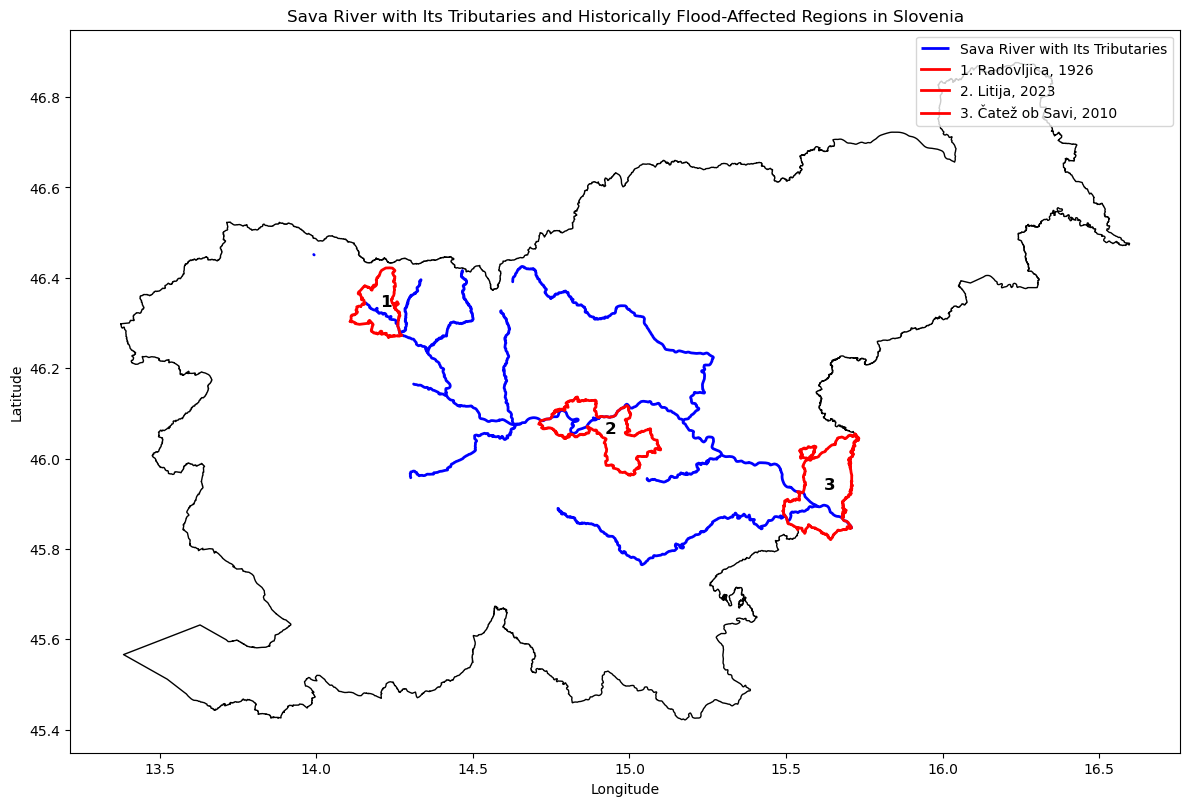

In [2]:
plot_regions(current_folder, "SI")

### Import complete UC5 pandapower network 
The Slovenian electricity transmission grid is loaded from a compressed pickle file that contains the complete pandapower model. This file integrates ENTSO‑E‑based network topology, OSM‑derived geometries, LAU‑level regional updates, spatially distributed national consumption data, and the economic and temporal profiles of power plants including regulation strategies and energy storage integration consolidated into one unified dataset.

In [3]:
net = pp.from_pickle(os.path.join(current_folder, "inputs/pickle_files/uc5_network.p"))
print(net)

# Save net SI single-state:
net_single_state = net.deepcopy()    

# Save net bus and line copies for network reset
net_bus_copy = net.bus.copy()
net_line_copy = net.line.copy()

# Fix geodata
fix_geodata(net)

This pandapower network includes the following parameter tables:
   - bus (191 elements)
   - load (212 elements)
   - storage (3 elements)
   - gen (91 elements)
   - line (282 elements)
   - trafo (28 elements)
   - poly_cost (94 elements)
   - line_geodata (282 elements)
   - bus_geodata (191 elements)


### Import load profiles
The load profiles for Slovenia are imported from a compressed pickle file, derived from the original dataset used in the EU‑wide model. The load mapping to locations of demand is performed using the KdTree Nearest Neighbour Search with additional focus on prioritizing load mapping to 110kV level.

In [4]:
# Import load profiles
load_profiles = pd.read_pickle(os.path.join(current_folder, "inputs/pickle_files/load_profiles_uc5.pkl"))

start_time, end_time = define_interval(load_profiles)

load_profiles = load_profiles.loc[start_time:end_time]

Start time: 2020-08-01 00:00:00 
End time: 2020-08-08 00:00:00 


### Run flood impact simulation

In [5]:
# Run predefined_simulation 
#chose one of the flooding scenarios (upper/middle/lower/all)  that will be used for the rest of the notebook
simulation_type = "lower"  

pf_results = run_predefined_simulation(net, current_folder, "SI", pd, load_profiles, pf_res_plotly, time_series_calculations, simulation_type)    

There are no Power Flow results. A Newton-Raphson power flow will be executed.


KeyError: 'load'

### Case Study Results

In [ ]:
case_study_results(simulation_type)

### Network and Asset-level risk assessment

In [ ]:
disconnected_elements(net)

### Systemic-risk assessment

In [ ]:
disruption_diagnostics(net)

## 3. Multi Hazard Risk Assessment: Landslides

The floods in Slovenia in 2023 were caused by severe rainfall that also triggered numerous landslides in different parts of the country. 
While these caused no additional major outages of the power grid, this may happen in the future as rainfall becomes more intense under climate change. 
In the example below we showcase how an additional failure of a substation would affect the system. 

In [ ]:
# Reload the baseline state of the power network
net = pp.from_pickle(os.path.join(current_folder, "inputs/pickle_files/uc5_network.p"))
# Fix geodata
fix_geodata(net)

In [ ]:
# Run predefined_simulation 

# Choose which substation fails due to a potential landslide event
failed_substation = "BOHINJ" #this can be changed to another substation to simulate an alternative scenario 

pf_results = single_point_of_failure(net, current_folder, "SI", pd, load_profiles, pf_res_plotly, time_series_calculations, simulation_type, failed_substation)    

Results of the single point of failure (landslide) analysis

In [ ]:
case_study_results("SPOF")

In [ ]:
disconnected_elements(net)

In [ ]:
disruption_diagnostics(net)

## 4. Compound hazard: Flooding and Landslides

This last example shows the compound effect of both flooding and landslide events in the network system.

In [ ]:
#reload the baseline state of the power network
net = pp.from_pickle(os.path.join(current_folder, "inputs/pickle_files/uc5_network.p"))
# Fix geodata
fix_geodata(net)

In [ ]:
# Run compound hazard failure simulation 
pf_results = run_predefined_simulation(net, current_folder, "SI", pd, load_profiles, pf_res_plotly, time_series_calculations, simulation_type, failed_substation)    

Results of the multi-hazard (floods and landslides) risk assessment

In [ ]:
case_study_results(simulation_type)

In [ ]:
disconnected_elements(net)

In [ ]:
disruption_diagnostics(net)